# LSD Nodule Detection — YOLOv8s Training Notebook (v2 — corrected)
**Component:** Lumpy Skin Disease Detection (YOLOv8s lesion localization stage)

**What's fixed in this version vs. v1:**
- Inference labels are now drawn manually (hardcoded "Nodule" text), so the old long class name can never leak through regardless of notebook cell order.
- Added a tunable confidence/IoU threshold cell so you can calibrate false positives vs. missed detections without retraining.
- Added a "review misclassifications" cell to help you see *why* the model is struggling (low-confidence background triggers, missed real nodules) instead of guessing.
- Training uses more epochs with proper early stopping and a slightly lower learning rate, which generally helps smaller/noisier datasets converge more reliably.

**Before you start:** replace the placeholder API key in Cell 4 with your own key. Rotate any key you've shared previously.


## 1. Check GPU

In [ ]:
!nvidia-smi

Thu Aug 13 03:12:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Mount Google Drive

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/LSD_Detection_Project'
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)
print('Project folder ready at:', DRIVE_PROJECT_DIR)

Mounted at /content/drive
Project folder ready at: /content/drive/MyDrive/LSD_Detection_Project


## 3. Install packages

In [3]:
!pip install -q roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.1 MB/s eta 0:00:00


## 4. Download dataset from Roboflow
Replace the placeholder with your own (rotated) API key.

In [ ]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = "pYQh9qym5hwaqeLPvbVg"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("it22368348-disanayake-r-g-o-s").project("lsd-nodule-detection")
version = project.version(1)
dataset = version.download("yolov8")

print("Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to LSD-Nodule-Detection-1 in yolov8:: 100%|██████████| 1241/1241 [00:00<00:00, 3711.57it/s]


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /content/LSD-Nodule-Detection-1


## 5. Inspect / fix data.yaml

In [ ]:
import yaml

data_yaml_path = os.path.join(dataset.location, "data.yaml")

with open(data_yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

data_cfg["train"] = os.path.join(dataset.location, "train", "images")
data_cfg["val"]   = os.path.join(dataset.location, "valid", "images")
data_cfg["test"]  = os.path.join(dataset.location, "test", "images")

with open(data_yaml_path, "w") as f:
    yaml.dump(data_cfg, f)

print("data.yaml:")
print(data_cfg)

data.yaml:
{'names': ['LSD-Nodule-Detection'], 'nc': 1, 'roboflow': {'license': 'CC BY 4.0', 'project': 'lsd-nodule-detection', 'url': 'https://universe.roboflow.com/it22368348-disanayake-r-g-o-s/lsd-nodule-detection/dataset/1', 'version': 1, 'workspace': 'it22368348-disanayake-r-g-o-s'}, 'test': '/content/LSD-Nodule-Detection-1/test/images', 'train': '/content/LSD-Nodule-Detection-1/train/images', 'val': '/content/LSD-Nodule-Detection-1/valid/images'}


## 6. Train YOLOv8s
Changes from v1 aimed at improving detection quality on a modest-sized dataset:
- `epochs=150` with `patience=30` (more room to converge, still stops early if it plateaus)
- `lr0=0.001` (slightly lower initial learning rate — reduces the chance of the model settling on a noisy/unstable solution, common with smaller datasets)
- `dropout=0.1` (mild regularization to reduce overfitting on the ~600-image augmented set)

These are reasonable starting adjustments, not a guarantee — real accuracy improvement over multiple runs usually also depends on annotation consistency and dataset size, which no hyperparameter change alone fixes.

In [ ]:
from ultralytics import YOLO

EPOCHS = 150
BATCH = 16
IMG_SIZE = 640

model = YOLO("yolov8s.pt")

results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    batch=BATCH,
    imgsz=IMG_SIZE,
    lr0=0.001,
    dropout=0.1,
    project=os.path.join(DRIVE_PROJECT_DIR, "runs"),
    name="yolov8s_lsd_run2",
    patience=30,
    save=True,
    plots=True,
    exist_ok=True
)

RUN_DIR = os.path.join(DRIVE_PROJECT_DIR, "runs", "yolov8s_lsd_run2")
print("Training complete. Results saved to:", RUN_DIR)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/LSD-Nodule-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_lsd_run2, n

## 7. Training metrics — loss curves, precision, recall, mAP

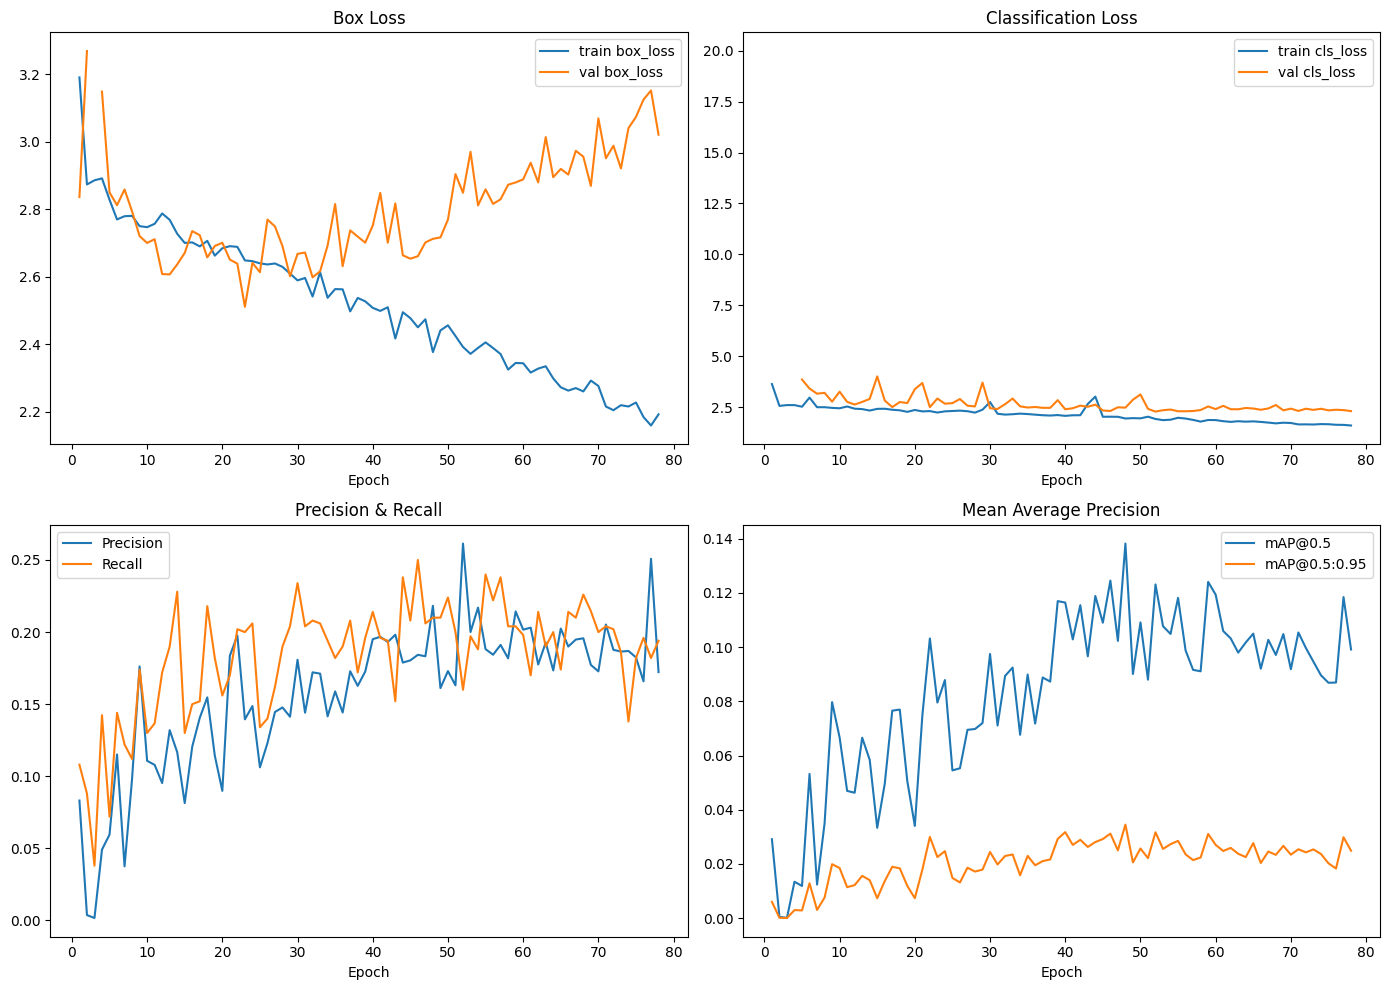

Saved to: /content/drive/MyDrive/LSD_Detection_Project/runs/yolov8s_lsd_run2/custom_training_metrics.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = os.path.join(RUN_DIR, "results.csv")
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(df['epoch'], df['train/box_loss'], label='train box_loss')
axes[0,0].plot(df['epoch'], df['val/box_loss'], label='val box_loss')
axes[0,0].set_title('Box Loss'); axes[0,0].set_xlabel('Epoch'); axes[0,0].legend()

axes[0,1].plot(df['epoch'], df['train/cls_loss'], label='train cls_loss')
axes[0,1].plot(df['epoch'], df['val/cls_loss'], label='val cls_loss')
axes[0,1].set_title('Classification Loss'); axes[0,1].set_xlabel('Epoch'); axes[0,1].legend()

axes[1,0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
axes[1,0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
axes[1,0].set_title('Precision & Recall'); axes[1,0].set_xlabel('Epoch'); axes[1,0].legend()

axes[1,1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5')
axes[1,1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
axes[1,1].set_title('Mean Average Precision'); axes[1,1].set_xlabel('Epoch'); axes[1,1].legend()

plt.tight_layout()
metrics_fig_path = os.path.join(RUN_DIR, "custom_training_metrics.png")
plt.savefig(metrics_fig_path, dpi=150)
plt.show()
print("Saved to:", metrics_fig_path)

## 8. Confusion matrix, PR curve, F1 curve

--- Confusion Matrix ---


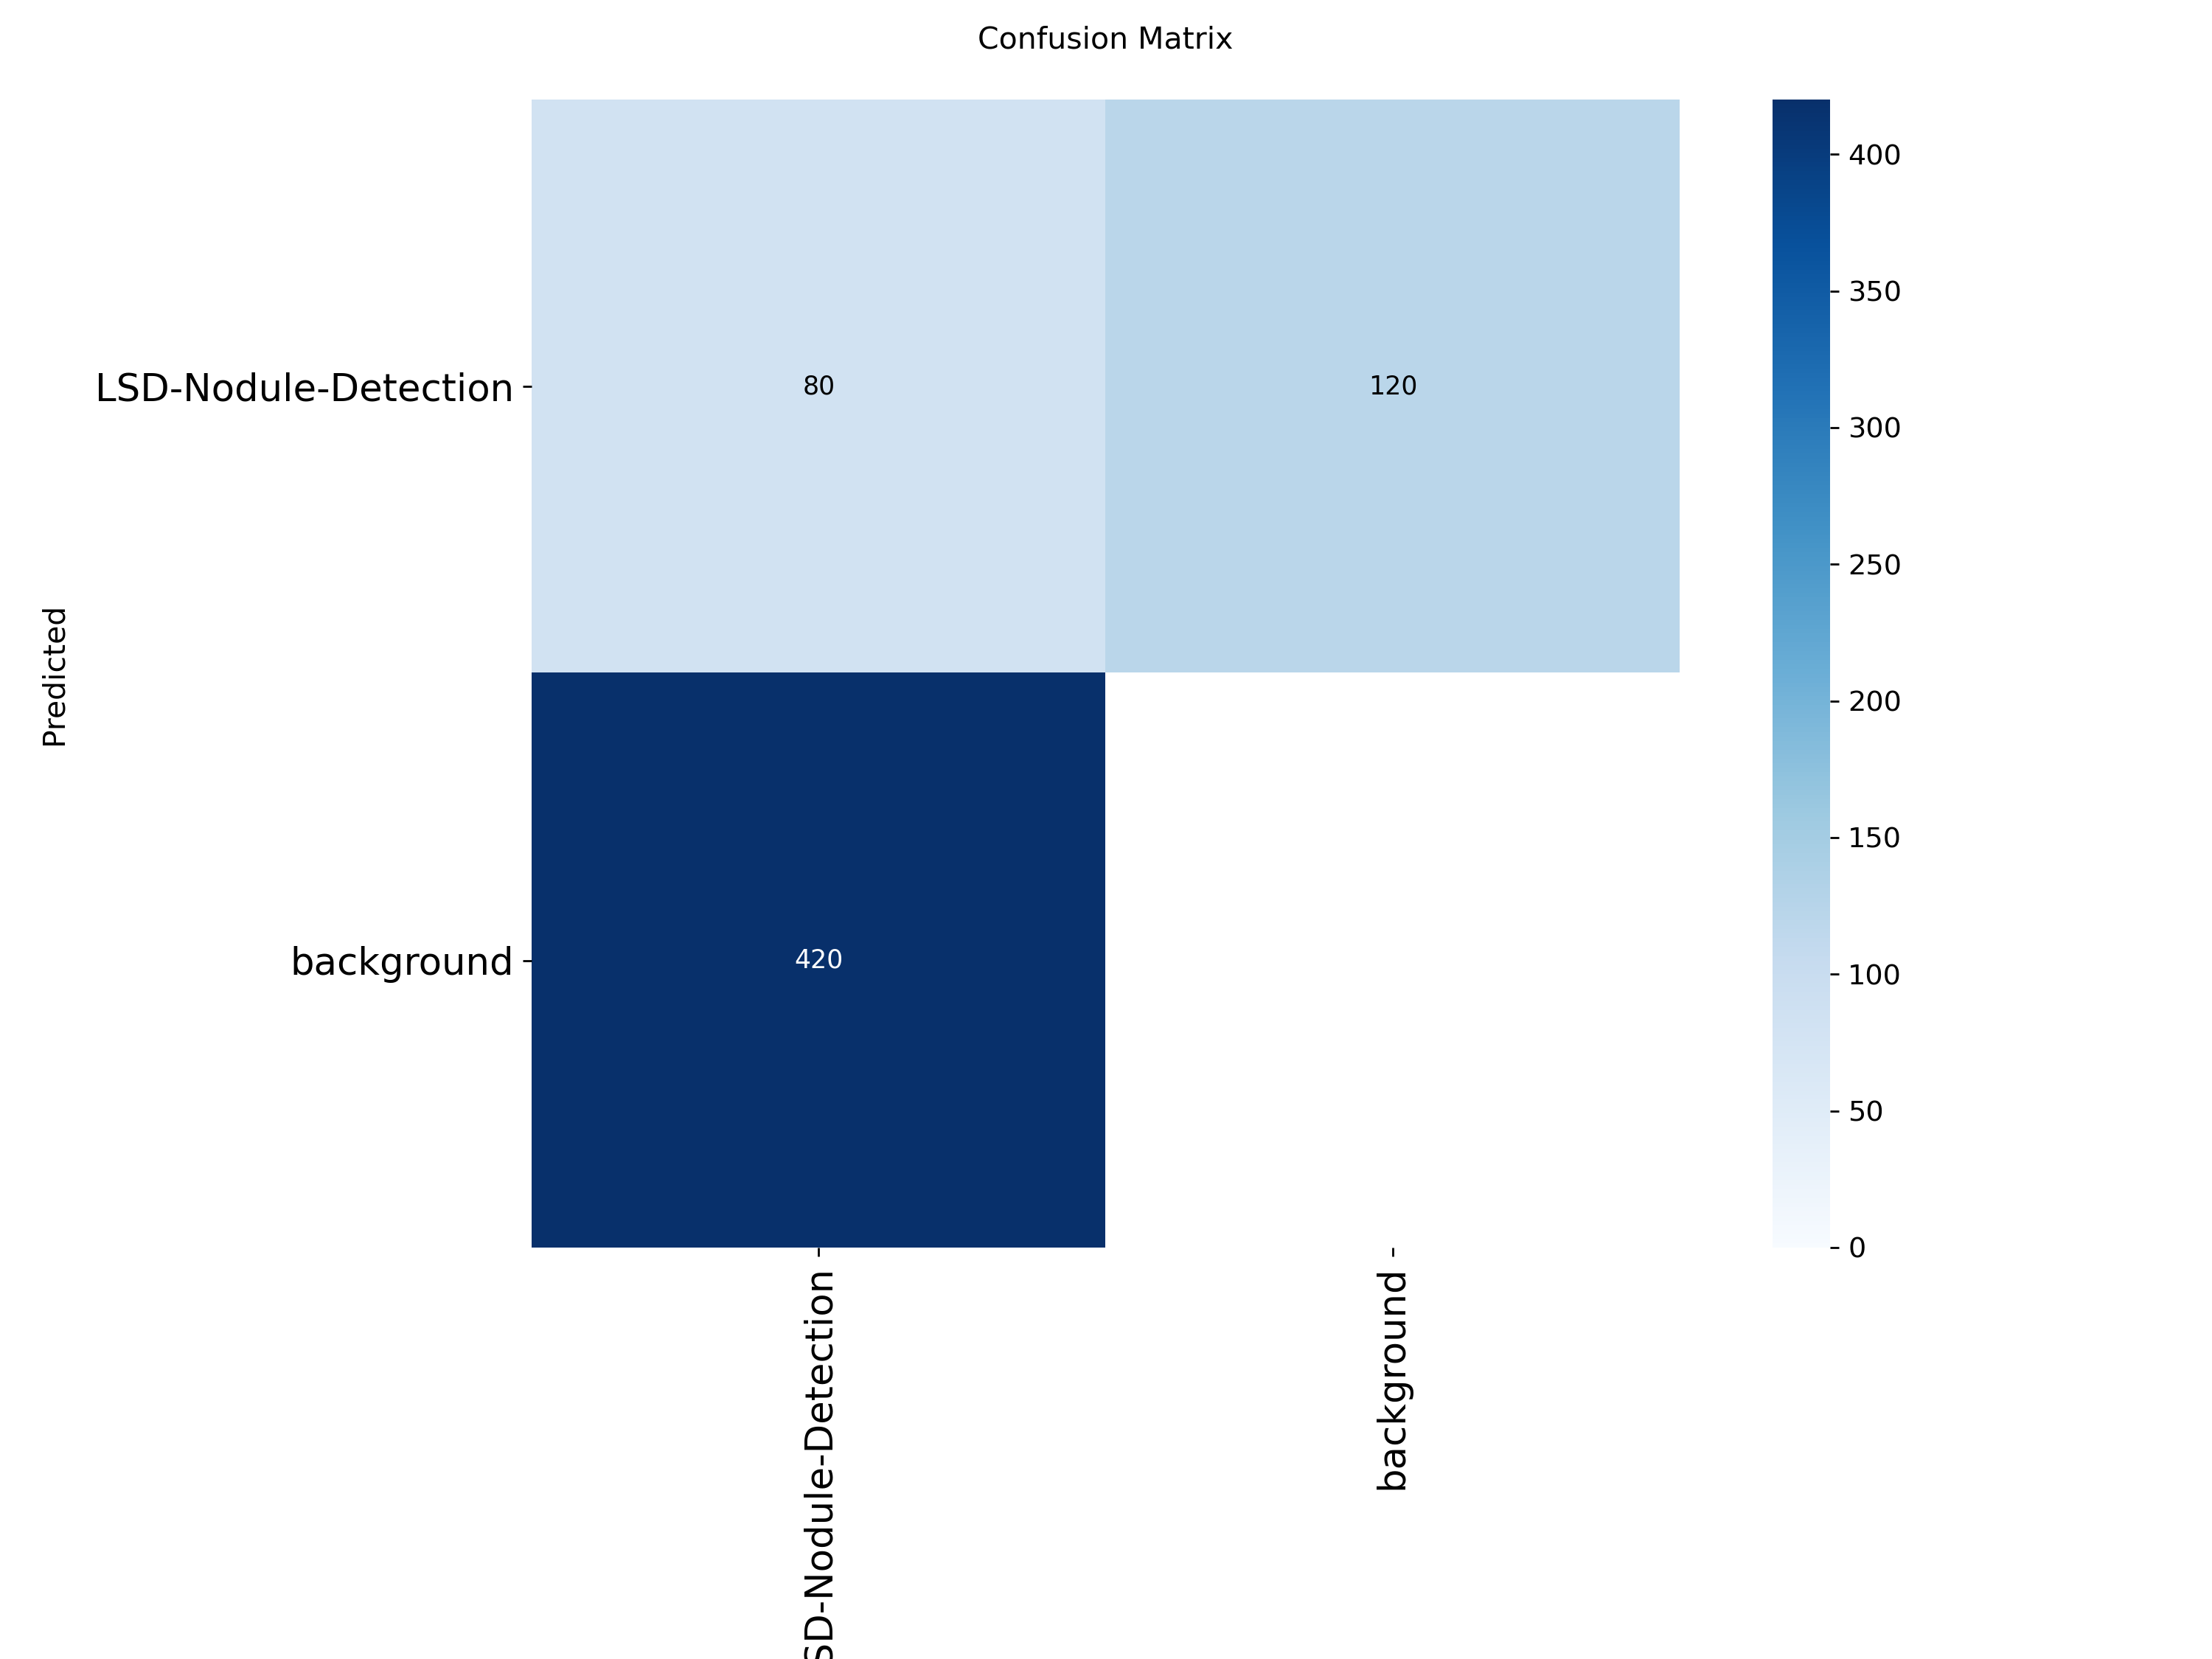

--- Normalized Confusion Matrix ---


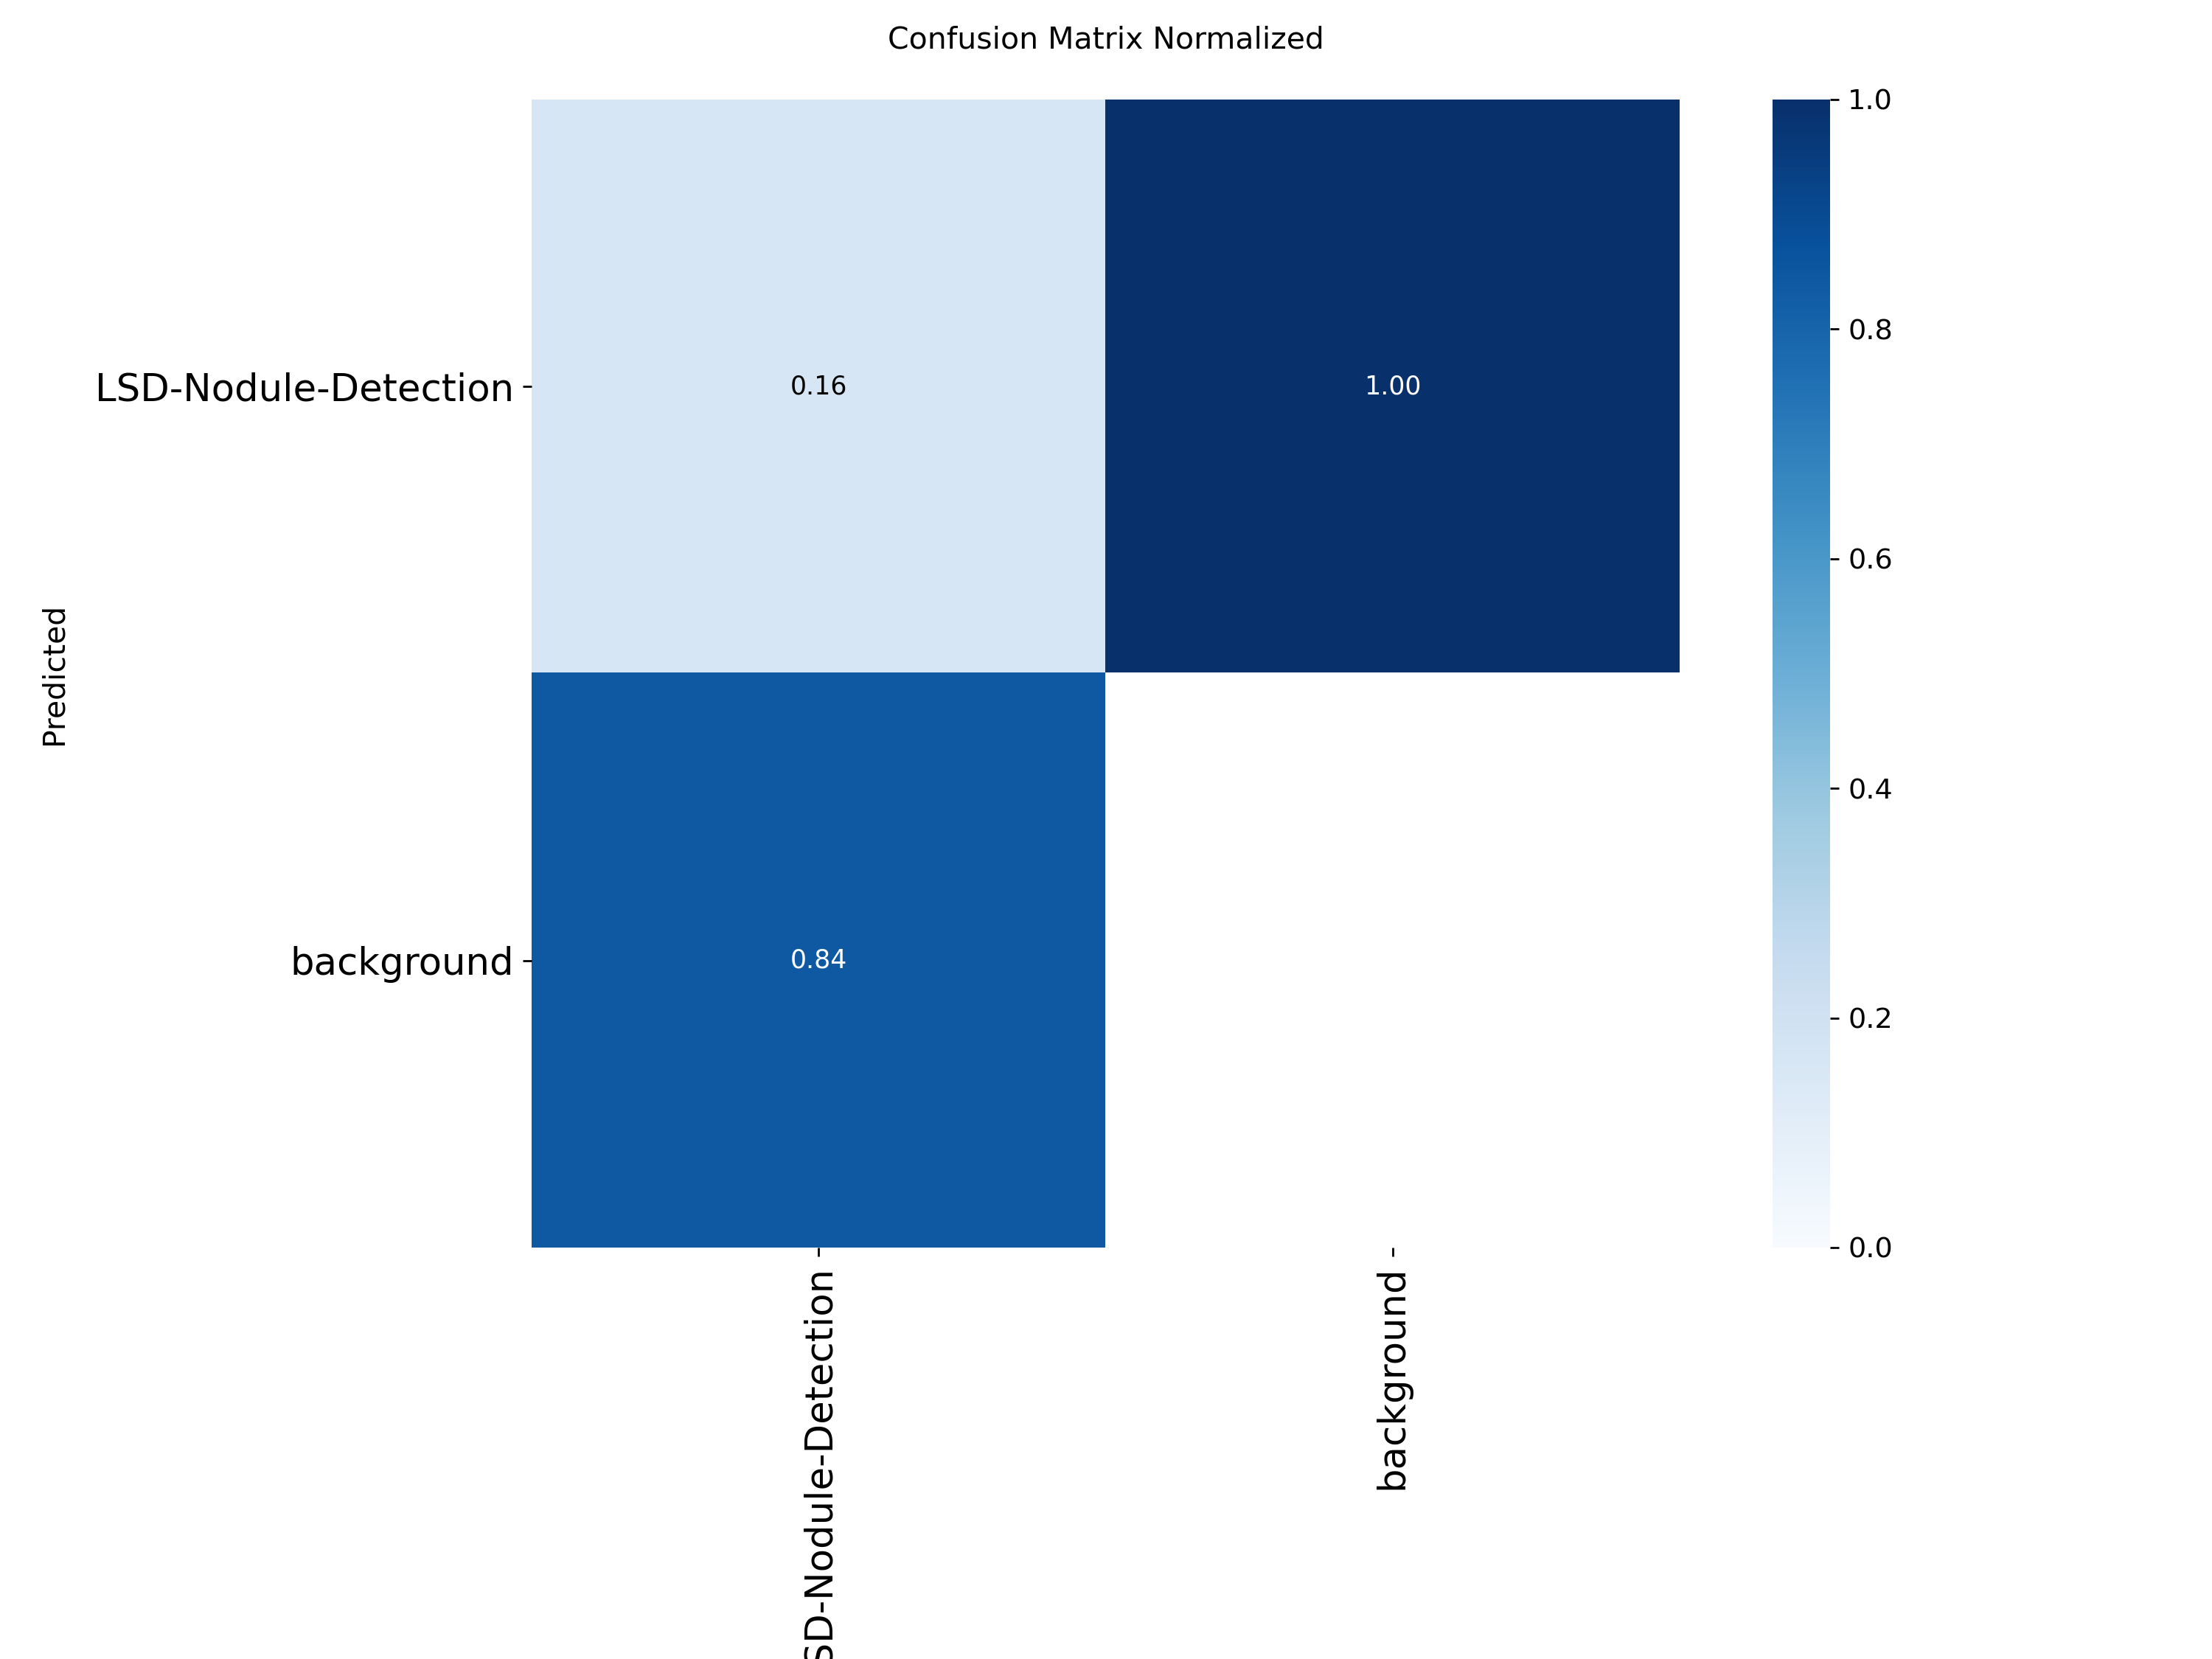

(not found: PR_curve.png)
(not found: F1_curve.png)
(not found: P_curve.png)
(not found: R_curve.png)
--- Training Results Summary ---


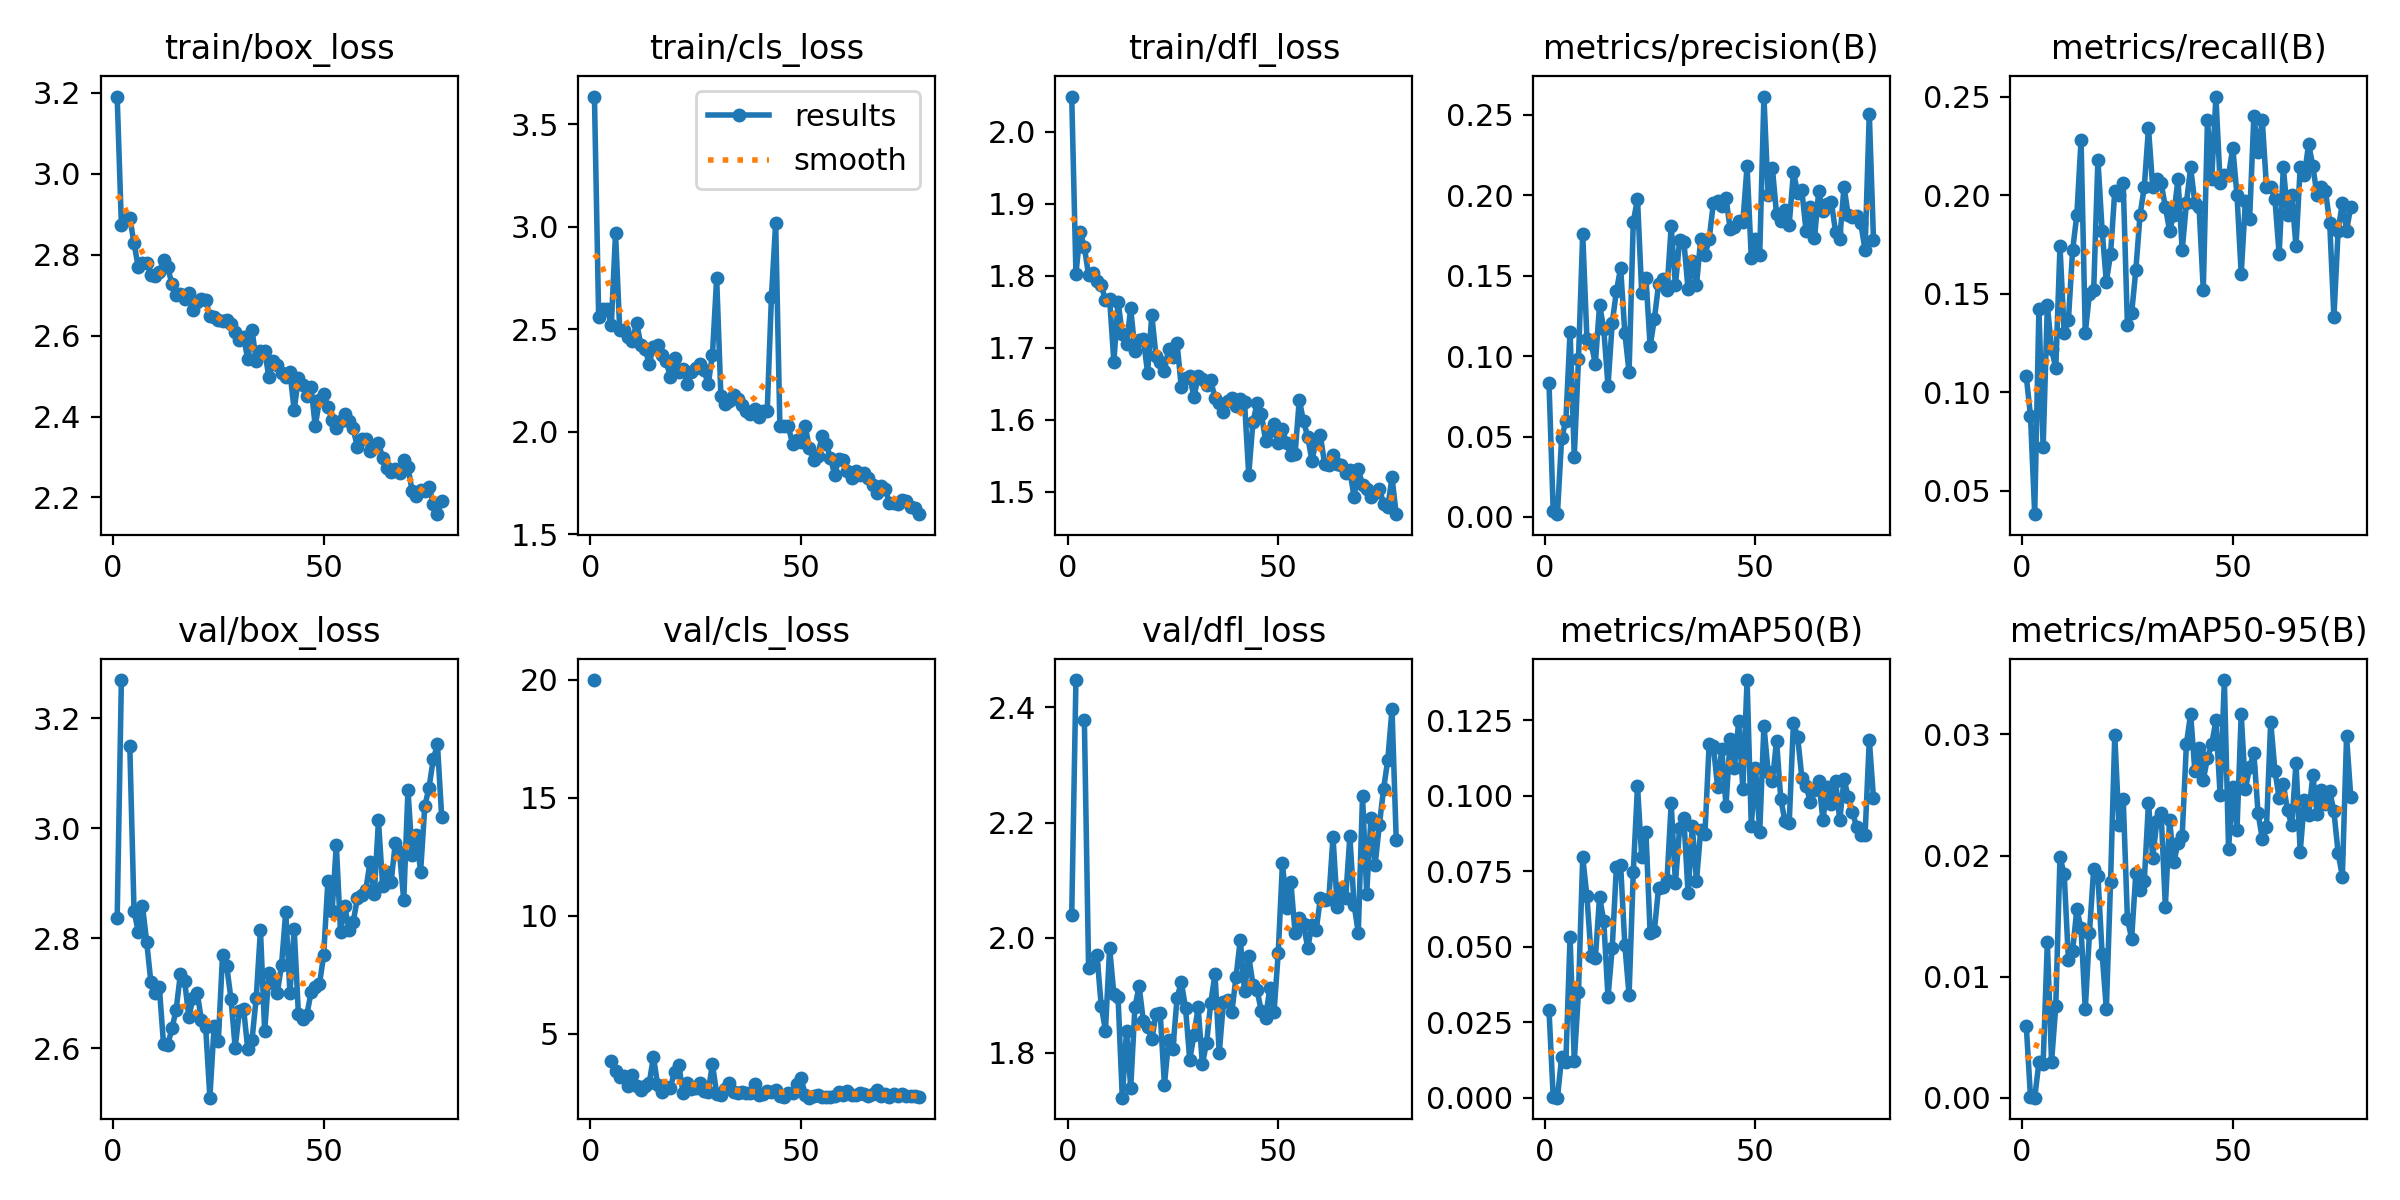

In [ ]:
from IPython.display import Image, display

plot_files = {
    "Confusion Matrix": "confusion_matrix.png",
    "Normalized Confusion Matrix": "confusion_matrix_normalized.png",
    "Precision-Recall Curve": "PR_curve.png",
    "F1 Curve": "F1_curve.png",
    "Precision Curve": "P_curve.png",
    "Recall Curve": "R_curve.png",
    "Training Results Summary": "results.png",
}

for title, fname in plot_files.items():
    fpath = os.path.join(RUN_DIR, fname)
    if os.path.exists(fpath):
        print(f"--- {title} ---")
        display(Image(filename=fpath, width=700))
    else:
        print(f"(not found: {fname})")

## 9. Final evaluation on the held-out TEST set

In [ ]:
best_weights = os.path.join(RUN_DIR, "weights", "best.pt")
test_model = YOLO(best_weights)

test_metrics = test_model.val(
    data=data_yaml_path,
    split="test",
    project=os.path.join(DRIVE_PROJECT_DIR, "runs"),
    name="yolov8s_lsd_test_eval",
    plots=True,
    exist_ok=True
)

print("\n=== FINAL TEST SET METRICS ===")
print(f"mAP@0.5:      {test_metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {test_metrics.box.map:.4f}")
print(f"Precision:    {test_metrics.box.mp:.4f}")
print(f"Recall:       {test_metrics.box.mr:.4f}")

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1639.8±400.3 MB/s, size: 68.7 KB)
val: Scanning /content/LSD-Nodule-Detection-1/test/labels... 24 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 24/24 2.0Kit/s 0.0s
val: New cache created: /content/LSD-Nodule-Detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4it/s 1.4s
                   all         24        261       0.19      0.276      0.118     0.0309
Speed: 5.2ms preprocess, 16.3ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to /content/drive/MyDrive/LSD_Detection_Project/runs/yolov8s_lsd_test_eval

=== FINAL TEST SET METRICS ===
mAP@0.5:      0.1183
mAP@0.5:0.95: 0.0309
Precision:    0.1905
Recall:       0.2759


## 10. Full training summary (text report, saved to Drive)

In [ ]:
best_epoch_idx = df['metrics/mAP50(B)'].idxmax()
best_row = df.loc[best_epoch_idx]
final_row = df.iloc[-1]

print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"\nTotal epochs run: {int(final_row['epoch']) + 1}")

print("\n--- FINAL EPOCH ---")
print(f"  Precision: {final_row['metrics/precision(B)']:.4f}")
print(f"  Recall:    {final_row['metrics/recall(B)']:.4f}")
print(f"  mAP@0.5:   {final_row['metrics/mAP50(B)']:.4f}")
print(f"  mAP@0.5:0.95: {final_row['metrics/mAP50-95(B)']:.4f}")

print(f"\n--- BEST EPOCH ({int(best_row['epoch'])}) ---")
print(f"  Precision: {best_row['metrics/precision(B)']:.4f}")
print(f"  Recall:    {best_row['metrics/recall(B)']:.4f}")
print(f"  mAP@0.5:   {best_row['metrics/mAP50(B)']:.4f}")
print(f"  mAP@0.5:0.95: {best_row['metrics/mAP50-95(B)']:.4f}")

print("\n--- TEST SET (held-out) ---")
print(f"  mAP@0.5:   {test_metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {test_metrics.box.map:.4f}")
print(f"  Precision: {test_metrics.box.mp:.4f}")
print(f"  Recall:    {test_metrics.box.mr:.4f}")
f1 = (2 * test_metrics.box.mp * test_metrics.box.mr) / (test_metrics.box.mp + test_metrics.box.mr + 1e-9)
print(f"  F1 Score:  {f1:.4f}")

print("\n--- NFR-01 CHECK (mAP >= 80%) ---")
status = "PASS" if test_metrics.box.map50 >= 0.80 else "BELOW TARGET"
print(f"  Test mAP@0.5 = {test_metrics.box.map50:.2%}  ->  {status}")
print("=" * 60)

summary_path = os.path.join(RUN_DIR, "training_summary.txt")
with open(summary_path, "w") as f:
    f.write(f"Total epochs: {int(final_row['epoch']) + 1}\n\n")
    f.write("FINAL EPOCH:\n")
    f.write(f"  Precision: {final_row['metrics/precision(B)']:.4f}\n")
    f.write(f"  Recall: {final_row['metrics/recall(B)']:.4f}\n")
    f.write(f"  mAP@0.5: {final_row['metrics/mAP50(B)']:.4f}\n")
    f.write(f"  mAP@0.5:0.95: {final_row['metrics/mAP50-95(B)']:.4f}\n\n")
    f.write(f"BEST EPOCH ({int(best_row['epoch'])}):\n")
    f.write(f"  Precision: {best_row['metrics/precision(B)']:.4f}\n")
    f.write(f"  Recall: {best_row['metrics/recall(B)']:.4f}\n")
    f.write(f"  mAP@0.5: {best_row['metrics/mAP50(B)']:.4f}\n")
    f.write(f"  mAP@0.5:0.95: {best_row['metrics/mAP50-95(B)']:.4f}\n\n")
    f.write("TEST SET:\n")
    f.write(f"  mAP@0.5: {test_metrics.box.map50:.4f}\n")
    f.write(f"  mAP@0.5:0.95: {test_metrics.box.map:.4f}\n")
    f.write(f"  Precision: {test_metrics.box.mp:.4f}\n")
    f.write(f"  Recall: {test_metrics.box.mr:.4f}\n")
    f.write(f"  F1 Score: {f1:.4f}\n")
print(f"\nSaved to: {summary_path}")

TRAINING SUMMARY

Total epochs run: 79

--- FINAL EPOCH ---
  Precision: 0.1722
  Recall:    0.1940
  mAP@0.5:   0.0991
  mAP@0.5:0.95: 0.0249

--- BEST EPOCH (48) ---
  Precision: 0.2182
  Recall:    0.2100
  mAP@0.5:   0.1383
  mAP@0.5:0.95: 0.0345

--- TEST SET (held-out) ---
  mAP@0.5:   0.1183
  mAP@0.5:0.95: 0.0309
  Precision: 0.1905
  Recall:    0.2759
  F1 Score:  0.2254

--- NFR-01 CHECK (mAP >= 80%) ---
  Test mAP@0.5 = 11.83%  ->  BELOW TARGET

Saved to: /content/drive/MyDrive/LSD_Detection_Project/runs/yolov8s_lsd_run2/training_summary.txt


## 11. Test on your own images — with manual, reliable label drawing
This does NOT rely on `model.names` at all, so the label text can never revert to the old class name. It draws boxes and text directly with OpenCV.

**Tune these two values to balance false positives vs. missed detections:**
- `CONF_THRESHOLD` — raise this (e.g. 0.4–0.5) if you're getting false positives on background/environment. Lower it (e.g. 0.15–0.2) if real nodules are being missed.
- `IOU_THRESHOLD` — controls how aggressively overlapping boxes get merged. Lower it if you're seeing duplicate boxes on the same nodule.

Saving Lumpy_Skin_105.png to Lumpy_Skin_105.png

--- Running detection on: Lumpy_Skin_105.png ---

image 1/1 /content/Lumpy_Skin_105.png: 640x640 8 LSD-Nodule-Detections, 16.2ms
Speed: 67.0ms preprocess, 16.2ms inference, 56.5ms postprocess per image at shape (1, 3, 640, 640)
Detected 8 nodule(s):
  Nodule 1: confidence = 68.41%
  Nodule 2: confidence = 51.03%
  Nodule 3: confidence = 46.24%
  Nodule 4: confidence = 42.83%
  Nodule 5: confidence = 42.79%
  Nodule 6: confidence = 41.85%
  Nodule 7: confidence = 39.08%
  Nodule 8: confidence = 38.47%


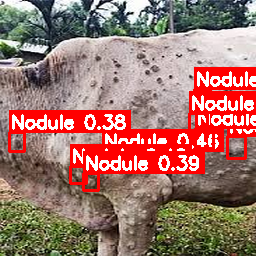

Saved annotated image to: /content/drive/MyDrive/LSD_Detection_Project/manual_inference_Lumpy_Skin_105.png


In [10]:
from google.colab import files
from ultralytics import YOLO
import cv2
import numpy as np
from IPython.display import Image as IPImage, display
import os # Import os module

CONF_THRESHOLD = 0.35   # <-- adjust this based on results
IOU_THRESHOLD = 0.45    # <-- adjust this based on results
LABEL_TEXT = "Nodule"   # hardcoded label, independent of model.names

# Ensure RUN_DIR and best_weights are defined if this cell is run out of order
# These values typically come from previous training cells (e.g., Section 6 and 9)
# You might need to adjust 'yolov8s_lsd_run2' if your training run name is different
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/LSD_Detection_Project'
RUN_DIR = os.path.join(DRIVE_PROJECT_DIR, "runs", "yolov8s_lsd_run2")
best_weights = os.path.join(RUN_DIR, "weights", "best.pt")

inference_model = YOLO(best_weights)

uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n--- Running detection on: {filename} ---")
    pred_results = inference_model.predict(
        source=filename,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        save=False,   # we draw manually below instead
    )

    result = pred_results[0]
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    boxes = result.boxes
    if boxes is not None and len(boxes) > 0:
        print(f"Detected {len(boxes)} nodule(s):")
        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            print(f"  Nodule {i+1}: confidence = {conf:.2%}")

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            label = f"{LABEL_TEXT} {conf:.2f}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1 - th - 8), (x1 + tw + 4, y1), (255, 0, 0), -1)
            cv2.putText(img, label, (x1 + 2, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    else:
        print("No nodules detected at current threshold.")

    out_path = os.path.join(DRIVE_PROJECT_DIR, "manual_inference_" + filename)
    cv2.imwrite(out_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    display(IPImage(filename=out_path, width=600))
    print(f"Saved annotated image to: {out_path}")

Saving Lumpy_Skin.png to Lumpy_Skin (1).png

--- Running detection on: Lumpy_Skin (1).png ---

image 1/1 /content/Lumpy_Skin (1).png: 640x640 3 LSD-Nodule-Detections, 16.1ms
Speed: 2.5ms preprocess, 16.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Detected 3 nodule(s):
  Nodule 1: confidence = 52.97%
  Nodule 2: confidence = 52.56%
  Nodule 3: confidence = 35.13%


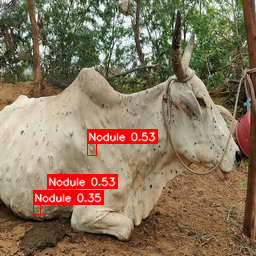

Saved annotated image to: /content/drive/MyDrive/LSD_Detection_Project/manual_inference_Lumpy_Skin (1).png


In [17]:
from google.colab import files
from ultralytics import YOLO
import cv2
import numpy as np
from IPython.display import Image as IPImage, display
import os # Import os module

CONF_THRESHOLD = 0.35
IOU_THRESHOLD = 0.45
LABEL_TEXT = "Nodule"

# --- Style settings (tweak these to taste) ---
BOX_THICKNESS = 1
FONT_SCALE = 0.35
FONT_THICKNESS = 1
BOX_COLOR = (255, 0, 0)
TEXT_COLOR = (255, 255, 255)

# Ensure RUN_DIR and best_weights are defined if this cell is run out of order
# These values typically come from previous training cells (e.g., Section 6 and 9)
# You might need to adjust 'yolov8s_lsd_run2' if your training run name is different
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/LSD_Detection_Project'
RUN_DIR = os.path.join(DRIVE_PROJECT_DIR, "runs", "yolov8s_lsd_run2")
best_weights = os.path.join(RUN_DIR, "weights", "best.pt")

inference_model = YOLO(best_weights)

uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n--- Running detection on: {filename} ---")
    pred_results = inference_model.predict(
        source=filename,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        save=False,
    )

    result = pred_results[0]
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    boxes = result.boxes
    if boxes is not None and len(boxes) > 0:
        print(f"Detected {len(boxes)} nodule(s):")
        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            print(f"  Nodule {i+1}: confidence = {conf:.2%}")

            cv2.rectangle(img, (x1, y1), (x2, y2), BOX_COLOR, BOX_THICKNESS)

            label = f"{LABEL_TEXT} {conf:.2f}"
            (tw, th), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, FONT_THICKNESS)

            # Small label background just above the box, tight to the text
            label_bg_y1 = max(0, y1 - th - baseline - 2)
            cv2.rectangle(img, (x1, label_bg_y1), (x1 + tw + 2, y1), BOX_COLOR, -1)
            cv2.putText(img, label, (x1 + 1, y1 - 3), cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, TEXT_COLOR, FONT_THICKNESS, cv2.LINE_AA)
    else:
        print("No nodules detected at current threshold.")

    out_path = os.path.join(DRIVE_PROJECT_DIR, "manual_inference_" + filename)
    cv2.imwrite(out_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    display(IPImage(filename=out_path, width=600))
    print(f"Saved annotated image to: {out_path}")

## 12. Why is the model getting false positives / missing nodules? (Diagnostic)
This cell doesn't fix the model — it helps you *see* where it's going wrong so you can decide the right fix (more data, re-annotation, threshold tuning, or more training).

It runs the model on your validation set and shows you the images where the model's predictions differ most from your ground-truth annotations — i.e. your worst-performing examples.

Reviewing sample validation images — look for:
  - Boxes on background/environment (false positives) -> raise CONF_THRESHOLD, or add more 'healthy' negative training images similar to these backgrounds
  - Missed real nodules (false negatives) -> lower CONF_THRESHOLD, check if these nodules were annotated inconsistently in training data, or are an under-represented case (e.g. very small/early-stage)


image 1/1 /content/LSD-Nodule-Detection-1/valid/images/Normal_Skin_374_png.rf.ff5e2906e47d7068d31f035c7339ed09.jpg: 640x640 (no detections), 16.2ms
Speed: 1.9ms preprocess, 16.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Normal_Skin_374_png.rf.ff5e2906e47d7068d31f035c7339ed09.jpg: 0 detection(s) at conf>=0.35


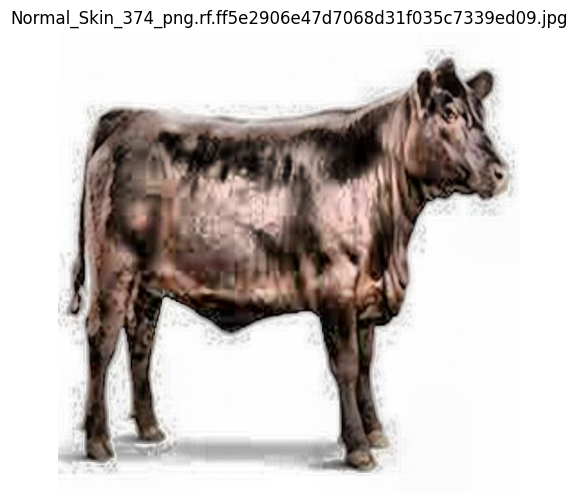


image 1/1 /content/LSD-Nodule-Detection-1/valid/images/Normal_Skin_278_png.rf.93bfd52179cd1d0ba7f1abc6eacd47de.jpg: 640x640 (no detections), 16.3ms
Speed: 2.2ms preprocess, 16.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Normal_Skin_278_png.rf.93bfd52179cd1d0ba7f1abc6eacd47de.jpg: 0 detection(s) at conf>=0.35


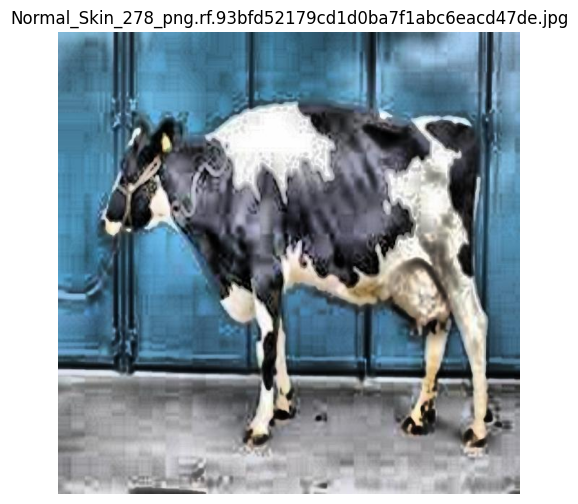


image 1/1 /content/LSD-Nodule-Detection-1/valid/images/Lumpy_Skin_53_png.rf.9a9536280f9e116d5d35459cc002a4f1.jpg: 640x640 (no detections), 16.3ms
Speed: 2.5ms preprocess, 16.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Lumpy_Skin_53_png.rf.9a9536280f9e116d5d35459cc002a4f1.jpg: 0 detection(s) at conf>=0.35


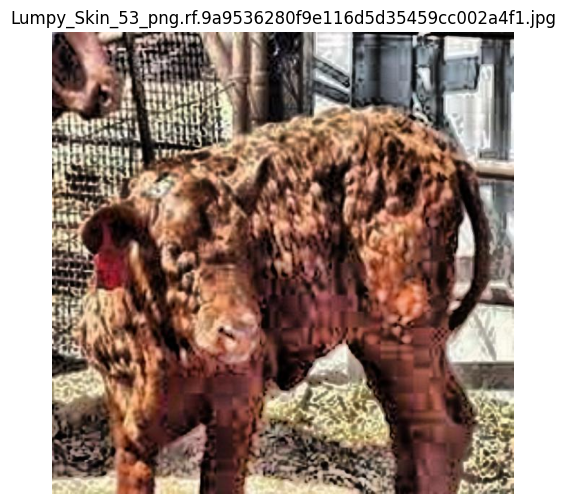


image 1/1 /content/LSD-Nodule-Detection-1/valid/images/Lumpy_Skin_196_png.rf.fd312ed72f7e3d668df8ff38407d7029.jpg: 640x640 7 LSD-Nodule-Detections, 16.3ms
Speed: 2.3ms preprocess, 16.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Lumpy_Skin_196_png.rf.fd312ed72f7e3d668df8ff38407d7029.jpg: 7 detection(s) at conf>=0.35


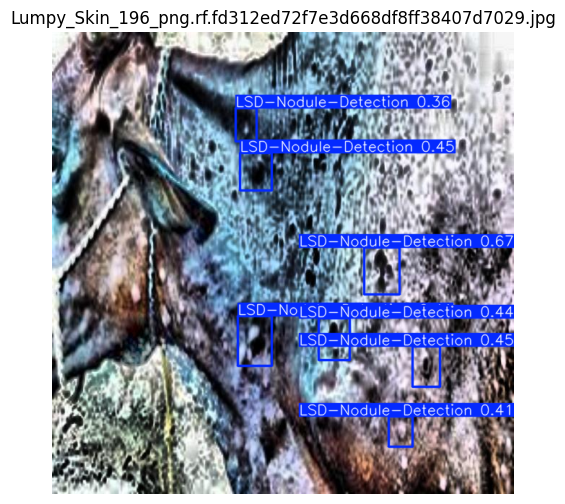


image 1/1 /content/LSD-Nodule-Detection-1/valid/images/Lumpy_Skin_282_png.rf.3cc44c69117e97c454a9fc1c6babf802.jpg: 640x640 (no detections), 17.2ms
Speed: 2.3ms preprocess, 17.2ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Lumpy_Skin_282_png.rf.3cc44c69117e97c454a9fc1c6babf802.jpg: 0 detection(s) at conf>=0.35


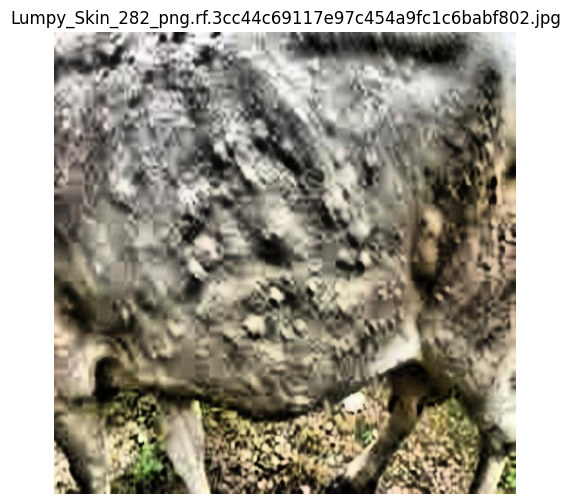


image 1/1 /content/LSD-Nodule-Detection-1/valid/images/Lumpy_Skin_292_png.rf.394f7418cd679e16de4b610ec0da9d8a.jpg: 640x640 (no detections), 16.3ms
Speed: 2.3ms preprocess, 16.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Lumpy_Skin_292_png.rf.394f7418cd679e16de4b610ec0da9d8a.jpg: 0 detection(s) at conf>=0.35


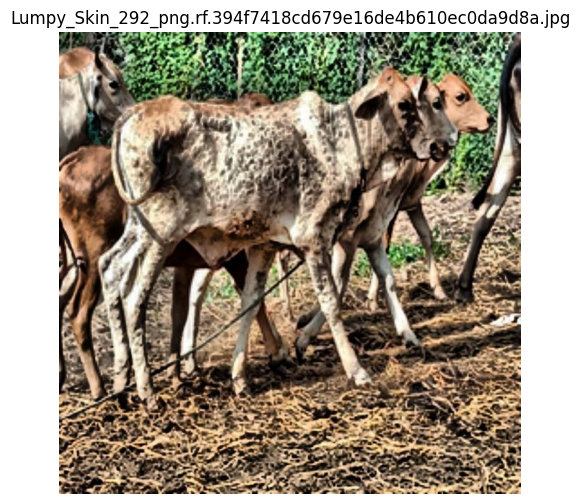

In [ ]:
import random

val_images_dir = os.path.join(dataset.location, "valid", "images")
val_images = [f for f in os.listdir(val_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Sample a handful to inspect (adjust N if you want to see more/fewer)
N = 6
sample_images = random.sample(val_images, min(N, len(val_images)))

print("Reviewing sample validation images — look for:")
print("  - Boxes on background/environment (false positives) -> raise CONF_THRESHOLD, or add more 'healthy' negative training images similar to these backgrounds")
print("  - Missed real nodules (false negatives) -> lower CONF_THRESHOLD, check if these nodules were annotated inconsistently in training data, or are an under-represented case (e.g. very small/early-stage)")
print()

for img_name in sample_images:
    img_path = os.path.join(val_images_dir, img_name)
    result = inference_model.predict(source=img_path, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, save=False)[0]
    n_detected = len(result.boxes) if result.boxes is not None else 0
    print(f"{img_name}: {n_detected} detection(s) at conf>={CONF_THRESHOLD}")
    annotated = result.plot()  # quick built-in visualization just for diagnostic purposes
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.title(img_name)
    plt.show()

## Notes on improving detection accuracy further
If false positives / missed nodules are still a problem after tuning `CONF_THRESHOLD`, the usual next steps (in rough order of effort vs. impact) are:

1. **Re-check annotation consistency** — since you and your friend split annotation work, compare a few of each other's boxes. Inconsistent box tightness or missed nodules between annotators directly hurts model quality more than almost anything else.
2. **Add more "hard negative" examples** — if the model keeps flagging specific background objects (ropes, ear tags, mud patches, fence rails) as nodules, add more healthy images containing those specific objects as zero-box negatives, so the model learns to ignore them.
3. **Increase dataset size** — 254 source images (618 after augmentation) is workable but modest for object detection. More real annotated images, especially of currently-confused cases, will help more than any hyperparameter tweak.
4. **Try more epochs / lower learning rate further** — already adjusted in this version, but you can experiment (e.g. `epochs=200`, `lr0=0.0005`) if you have Colab GPU time to spare.
5. **Review the confusion matrix and PR curve** from Section 8 — they'll tell you quantitatively whether the issue is more about precision (false positives) or recall (missed detections), which should guide which fix above to prioritize.
